## 1. Supervised Learning zur Klassifikation des Hypertoniestatus

Nach der Datenvorverarbeitung wurden in diesem Schritt verschiedene Klassifikationsmodelle trainiert, um vorherzusagen, ob bei einer Person Hypertonie vorliegt oder nicht. Grundlage dafür waren die zuvor ausgewählten Prädiktorvariablen wie Alter, Geschlecht, BMI, Taillenumfang sowie weitere gesundheitsbezogene Merkmale.

Die Daten wurden in Trainings- und Testdaten aufgeteilt, wobei eine stratifizierte Aufteilung genutzt wurde, um die Klassenverteilung der Zielvariable beizubehalten.

Da es sich bei der Zielvariable um eine binäre Klassifikation handelt, wurden  folgende geeignete Klassifikationsverfahren eingesetzt:
- Logistic Regression
- Random Forest
- Decision Tree

und anschließend miteinander verglichen. Ziel war es nicht nur, eine möglichst hohe Gesamtgenauigkeit zu erreichen, sondern insbesondere auch Personen mit Hypertonie zuverlässig zu erkennen.

Die Modellleistungen wurde anhand von Accuracy, Precision, Recall, F1-Score, ROC-AUC und der Confusion Matrix bewertet.

**Modellbewertung:**
Der Fokus der Modellbewertung dieser Analyse liegt auf einer möglichst hohen Sensitivität bzw. einem hohen Recall. Da das Modell in einem präventiven Screening-Kontext eingesetzt wird, sollen Personen mit Hypertonie möglichst selten fälschlicherweise als unauffällig klassifiziert werden.

9. Feature Importance anschauen
10. Ergebnis kurz zusammenfassen

#### 1. Datenladung, Vorbereitung für Modellierung 

Hier ein Überblick über die Zielvariable und Features :

- `hypertension`: Hat der Teilnehmer Hypertonie?
     - 0 = Nein 
     - 1 = Ja
- `bmi`: Die BMI-Messunen von Teilnehmern 
- `gender`: Das Geschlecht.
     - 1 = Male
     - 2 = Female
- `age`: Das Alter.
- `waist_circumference(cm)`: Der gemessene Teilenumfang in cm von Teilnehmer  .
- `Alkoholkonusum`: 
- `Rauchverahlten`: 
- `Körperliche Aktivitäten `: 

In [2]:
#Libraries importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,precision_recall_curve,roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


## 1. Datenladung

Auf Basis des aufbereiteten NHANES-Datensatzes mit 6.266 Beobachtungen und … Variablen wurde zunächst eine weitere Datenbereinigung durchgeführt, um den Datensatz für die anschließende Modellierung vorzubereiten.

In [3]:
#Datenladung 

df = pd.read_csv('nhanes_cleand.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6266 entries, 0 to 6265
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pat_id                   6266 non-null   float64
 1   hypertension             6266 non-null   float64
 2   gender                   6266 non-null   str    
 3   age                      6266 non-null   float64
 4   weight(kg)               6266 non-null   float64
 5   height(cm)               6266 non-null   float64
 6   bmi                      6266 non-null   float64
 7   waist_circumference(cm)  6266 non-null   float64
 8   age_category             6266 non-null   str    
 9   bmi_category             6266 non-null   str    
dtypes: float64(7), str(3)
memory usage: 489.7 KB


In [5]:
# Datenbereinigung
# famle und male durch 2 und 1 ersetzen 
# und datentype umwandeln in int

df['gender'] = df['gender'].replace({
    'Male' : '1',
    'Female' : '2'
})

df['gender'] = pd.to_numeric(df['gender'], errors= 'coerce')

#nur nummerische Featurs behalten

df_featurs = df.drop(columns= ['age_category', 'bmi_category'] )

### 2. Datenvorverarbeitung:

Im Rahmen der Datenvorverarbeitung wurde der bereinigte NHANES-Datensatz in Prädiktorvariablen (`X`) und Zielvariable (`y`) aufgeteilt. Die Zielvariable beschreibt, ob bei einer Person Hypertonie vorliegt oder nicht.

Anschließend wurde der Datensatz in Trainings- und Testdaten aufgeteilt. Dabei wurden 80 % der Daten für das Training des Modells und 20 % für die spätere Modellbewertung verwendet.

Da die explorative Datenanalyse gezeigt hat, dass die Zielvariable nicht vollständig gleich verteilt ist, wurde beim Train-Test-Split eine stratifizierte Aufteilung verwendet (`stratify=y`). Dadurch bleibt das Verhältnis der beiden Zielklassen sowohl im Trainings- als auch im Testdatensatz möglichst ähnlich.

Die Zielvariable war ungefähr wie folgt verteilt:

* ca. 65 % der Personen ohne Hypertonie
* ca. 35 % der Personen mit Hypertonie

Damit liegt eine leichte bis moderate Klassenungleichverteilung vor. Diese ist nicht extrem, muss jedoch bei der Bewertung des Modells berücksichtigt werden. Ein Modell könnte sonst überwiegend die Mehrheitsklasse „keine Hypertonie“ vorhersagen und trotzdem eine scheinbar akzeptable Accuracy erreichen.

Aus diesem Grund wurde die Modellleistung nicht ausschließlich anhand der Accuracy bewertet. Zusätzlich wurden weitere Bewertungsmetriken wie Precision, Recall, F1-Score und die Confusion Matrix betrachtet, um insbesondere die Erkennung von Personen mit Hypertonie besser beurteilen zu können.


In [6]:
# Train-Test-Split 
# Features (X) und Target (y) aufteieln 

# alle Features ausser Hypertonie (Zielvariable)

X = df_featurs.drop(columns= ['hypertension', 'pat_id']) # Ausschluss potenzieller Leakage-Variablen vor der Modellierung

# Target 
y = df['hypertension']

In [7]:
# train-test-Split aufteilung 

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 42,
    stratify=y
)

print( 'X_train', X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train (5012, 6)
X_test: (1254, 6)
y_train: (5012,)
y_test: (1254,)


# 3.Modelltraining

## 3.1 Logistic Regression

Im nächsten Schritt wurden Klassifikationsmodelle trainiert, um das Vorliegen von Hypertonie anhand der ausgewählten Merkmale vorherzusagen. Die Modelle wurden ausschließlich mit den Trainingsdaten trainiert, während die Testdaten für die spätere Bewertung zurückgehalten wurden.

Da die Zielvariable zwei Ausprägungen besitzt — Hypertonie ja oder nein — handelt es sich um ein binäres Klassifikationsproblem. Ziel des Modelltrainings war es, Muster in den Daten zu erkennen und daraus möglichst zuverlässige Vorhersagen für bisher unbekannte Personen abzuleiten.

Nach der ersten Modellierung wurden folgende Anpassungen vorgenommen, um die Modellleistung zu verbessern.

Mögliche Verbesserungsansätze waren:
- die Verwendung von class_weight="balanced" (für die Berücksichtigung der ungleichen Klassenverteilung)
- die Anpassung des Entscheidungsschwellenwertes
- der Vergleich verschiedener Klassifikationsmodelle sowie die Prüfung zusätzlicher relevanter Risikofaktoren.


Accuracy: 0.7376395534290271
Precision weighted: 0.7695967903131765
Recall weighted: 0.7376395534290271
F1 weighted: 0.7436128582379229
Recall Hypertonie: 0.7912844036697247
Precision Hypertonie: 0.5917667238421955
F1 Hypertonie: 0.677134445534838


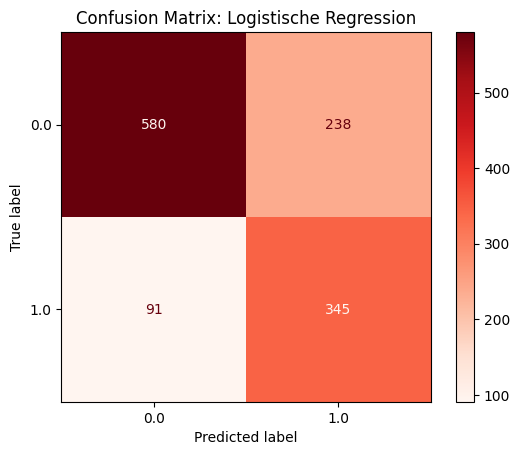

In [8]:
#Modelltraining  nach Klasse logistische Regression 
# daten standardisiert
log_model = Pipeline ([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter= 1000,
                                 class_weight= 'balanced'))
])

#model trainieren 
log_model.fit(X_train, y_train)

# Vorhersagen für die Testdaten

y_pred_log = log_model.predict(X_test)

# Modellbewertung
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision weighted:", precision_score(y_test, y_pred_log, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_log, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_log, average="weighted"))

# Fokus auf positive Klasse: Hypertonie
print("Recall Hypertonie:", recall_score(y_test, y_pred_log, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test,y_pred_log, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_log, pos_label=1))


# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    cmap="Reds"
)

plt.title("Confusion Matrix: Logistische Regression")
plt.show()


Die Confusion Matrix zeigt, dass das Modell 345 Personen mit Hypertonie korrekt erkannt hat, während 91 Personen mit Hypertonie fälschlicherweise als nicht hyperton klassifiziert wurden. Der Recall der positiven Klasse beträgt 0,79. Damit erkennt das Modell etwa 79 % der tatsächlichen Hypertonie-Fälle. Gleichzeitig wurden 238 Personen ohne Hypertonie fälschlicherweise als hyperton klassifiziert. Dies zeigt, dass das Modell eine relativ hohe Sensitivität für Hypertonie erreicht, jedoch auf Kosten einer höheren Anzahl falsch-positiver Vorhersagen. Da in diesem Projekt ein präventiver Screening-Kontext betrachtet wird, ist ein höherer Recall der Hypertonie-Klasse besonders relevant.

Die gewichtete Precision liegt über der Precision der Hypertonie-Klasse, da sie beide Klassen berücksichtigt und die Klasse ohne Hypertonie eine deutlich höhere Precision aufweist. Deshalb wurde zusätzlich die Precision der positiven Klasse separat betrachtet, um die Modellleistung für die Erkennung von Hypertonie gezielt zu bewerten.

### Anpassung der Entscheidungsschwellenwert

Zusätzlich wurde der Entscheidungsschwellenwert angepasst. Standardmäßig klassifiziert das Modell Personen ab einer Wahrscheinlichkeit von 0,5 als hyperton.
Da in diesem Projekt die Erkennung möglichst vieler Hypertonie-Fälle im Vordergrund steht, wurde ein niedrigerer Schwellenwert getestet. Dadurch können mehr tatsächliche Hypertonie-Fälle erkannt werden, allerdings steigt gleichzeitig die Anzahl falsch-positiver Vorhersagen.

Metriken mit Schwellenwert: 0.4
Accuracy: 0.7049441786283892
Precision weighted: 0.7847594243573837
Recall weighted: 0.7049441786283892
F1 weighted: 0.7105381054491439
Recall Hypertonie: 0.8899082568807339
Precision Hypertonie: 0.5464788732394367
F1 Hypertonie: 0.6771378708551483


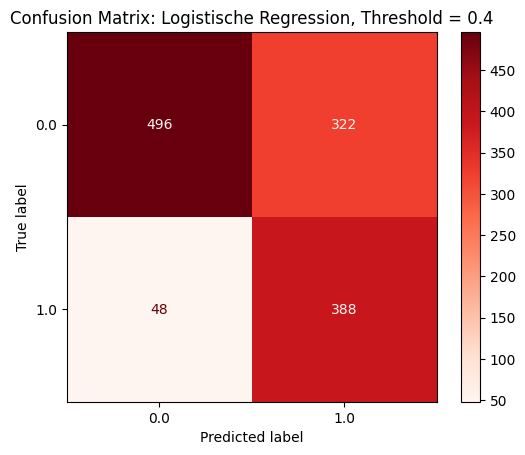

In [9]:
# Wahrscheinlichkeiten für Klasse 1 = Hypertonie
y_proba_log = log_model.predict_proba(X_test)[:, 1]

# eigener Schwellenwert
threshold = 0.4

# neue Vorhersage anhand des Schwellenwerts
y_pred_threshold = (y_proba_log >= threshold).astype(int)
print("Metriken mit Schwellenwert:", threshold)

print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
print("Precision weighted:", precision_score(y_test, y_pred_threshold, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_threshold, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_threshold, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_threshold, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_threshold, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_threshold, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_threshold,
    cmap="Reds"
)

plt.title(f"Confusion Matrix: Logistische Regression, Threshold = {threshold}")
plt.show()

In [10]:
roc_auc_log = roc_auc_score(y_test, y_proba_log)
print("ROC-AUC Logistic Regression:",roc_auc_log)

ROC-AUC Logistic Regression: 0.8161941185706915


Die logistische Regression erreichte eine ROC-AUC von 0,816. Dies zeigt, dass das Modell eine gute Trennfähigkeit zwischen Personen mit und ohne Hypertonie besitzt.

##### Vergleich: Standard-Threshold vs. Threshold 0.4

Im ersten Schritt wurde das Modell mit der Standardklassifikation bewertet. Dabei erreichte die logistische Regression eine Accuracy von 0,738 und einen Recall der Hypertonie-Klasse von 0,791. Die Confusion Matrix zeigte, dass 345 von 436 Personen mit Hypertonie korrekt erkannt wurden, während 91 Fälle übersehen wurden.

Anschließend wurde mithilfe der vorhergesagten Wahrscheinlichkeiten aus `predict_proba()`der Entscheidungsschwellenwert auf 
0,4 gesenkt. Dadurch erhöhte sich der Recall der Hypertonie-Klasse auf 0,890. Die Anzahl übersehener Hypertonie-Fälle sank von 91 auf 48. Gleichzeitig nahm jedoch die Anzahl falsch-positiver Vorhersagen von 238 auf 322 zu, wodurch die Precision der Hypertonie-Klasse von 0,592 auf 0,546 sank.

Da das Projekt in einem präventiven Screening-Kontext steht, ist ein höherer Recall besonders relevant. Die Schwellenwertanpassung zeigt daher, dass das Modell sensitiver für Hypertonie-Fälle gemacht werden kann, allerdings auf Kosten einer höheren Anzahl falsch-positiver Klassifikationen.

## 3.2 Random Forest

Zusätzlich zur logistischen Regression wurde ein Random-Forest-Modell getestet. Random Forest ist ein nicht-lineares Ensemble-Verfahren und kann komplexere Zusammenhänge zwischen den Prädiktoren und der Zielvariable abbilden. Dadurch kann geprüft werden, ob ein flexibleres Modell die Vorhersage von Hypertonie verbessert. Zur Berücksichtigung der ungleichen Klassenverteilung wurde ebenfalls class_weight="balanced" verwendet.

Metriken Random Forest mit Standard-Threshold
Accuracy: 0.7089314194577353
Precision weighted: 0.7003974017790079
Recall weighted: 0.7089314194577353
F1 weighted: 0.7025442866971681
Recall Hypertonie: 0.5045871559633027
Precision Hypertonie: 0.5962059620596206
F1 Hypertonie: 0.546583850931677


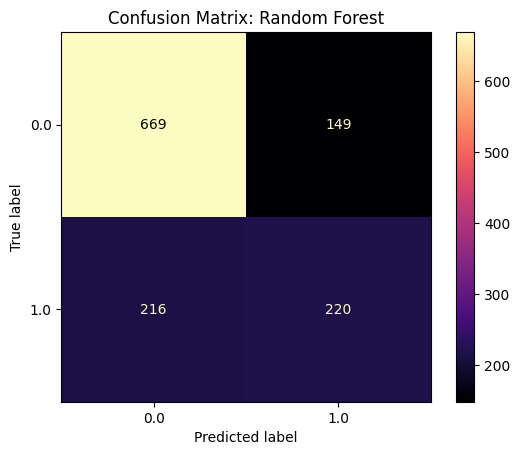

In [11]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

# Modell trainieren
forest_model.fit(X_train, y_train)

# Vorhersagen für die Testdaten
y_pred_forest = forest_model.predict(X_test)

print("Metriken Random Forest mit Standard-Threshold")

print("Accuracy:", accuracy_score(y_test, y_pred_forest))
print("Precision weighted:", precision_score(y_test, y_pred_forest, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_forest, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_forest, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_forest, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_forest, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_forest, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_forest,
    cmap='magma'
)

plt.title("Confusion Matrix: Random Forest")
plt.show()

In [12]:
y_proba_rf = forest_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC-AUC Random Forest:", roc_auc_rf)

ROC-AUC Random Forest: 0.7750414974989344


Der Random Forest erreichte eine ROC-AUC von 0,775. Dies zeigt eine akzeptable Trennfähigkeit zwischen Personen mit und ohne Hypertonie. Im Vergleich zur logistischen Regression, die eine ROC-AUC von 0,816 erreichte, schnitt der Random Forest hinsichtlich der allgemeinen Trennfähigkeit etwas schwächer ab.

##### Anpassung der Entscheidungsschwellenwert


Metriken Random Forest mit Schwellenwert: 0.4
Accuracy: 0.7097288676236044
Precision weighted: 0.7222680944786207
Recall weighted: 0.7097288676236044
F1 weighted: 0.7139338917894349
Recall Hypertonie: 0.6605504587155964
Precision Hypertonie: 0.5714285714285714
F1 Hypertonie: 0.6127659574468085


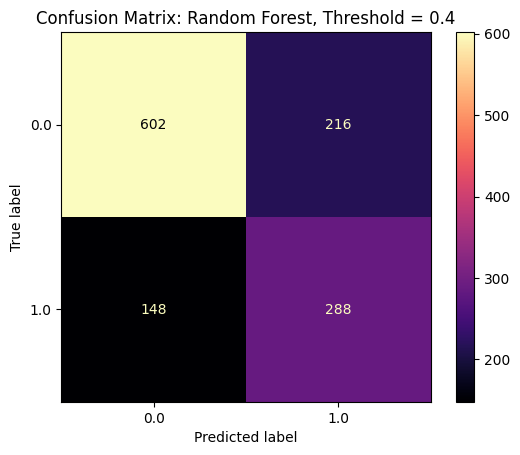

In [13]:
threshold = 0.4

y_pred_rf_threshold = (y_proba_rf >= threshold).astype(int)

print("Metriken Random Forest mit Schwellenwert:", threshold)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_threshold))
print("Precision weighted:", precision_score(y_test, y_pred_rf_threshold, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_rf_threshold, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_rf_threshold, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_rf_threshold, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_rf_threshold, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_rf_threshold, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf_threshold,
    cmap='magma'
)

plt.title("Confusion Matrix: Random Forest, Threshold = 0.4")
plt.show()

Beim Random-Forest-Modell wurde zunächst die Standardklassifikation bewertet. Dabei erreichte das Modell eine Accuracy von 0,709. Der Recall der Hypertonie-Klasse lag jedoch nur bei 0,505. Das bedeutet, dass das Modell nur etwa 50 % der tatsächlichen Hypertonie-Fälle korrekt erkannt hat. Die Precision der Hypertonie-Klasse lag bei 0,596.

Nach Anpassung des Schwellenwertes auf 0,4 verbesserte sich der Recall der Hypertonie-Klasse auf 0,661. Dadurch wurden mehr Personen mit Hypertonie erkannt. Gleichzeitig sank die Precision leicht auf 0,571, da mehr Personen ohne Hypertonie fälschlicherweise als hyperton klassifiziert wurden. Die Accuracy blieb mit 0,710 nahezu unverändert.

## 3.3 Decision Tree

Zusätzlich wurde ein Decision-Tree-Modell getestet. Decision Trees können nicht-lineare Zusammenhänge zwischen den unabhängigen Variablen und der Zielvariable abbilden und sind aufgrund ihrer Baumstruktur gut interpretierbar. Zur Berücksichtigung der ungleichen Klassenverteilung wurde class_weight="balanced" verwendet. Anschließend wurde die Modellleistung anhand von Accuracy, Precision, Recall, F1-Score, Confusion Matrix und ROC-AUC bewertet.


Metriken Decision Tree mit Standard-Threshold
Accuracy: 0.7121212121212122
Precision weighted: 0.7564670678208696
Recall weighted: 0.7121212121212122
F1 weighted: 0.7189619857658799
Recall Hypertonie: 0.7981651376146789
Precision Hypertonie: 0.5603864734299517
F1 Hypertonie: 0.6584673604541155


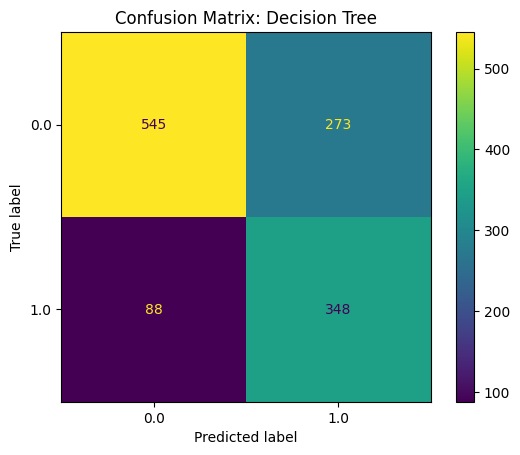

In [14]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Modell trainieren
tree_model.fit(X_train, y_train)

# Vorhersagen für die Testdaten
y_pred_tree = tree_model.predict(X_test)

print("Metriken Decision Tree mit Standard-Threshold")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision weighted:", precision_score(y_test, y_pred_tree, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_tree, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_tree, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_tree, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_tree, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_tree, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree,
    cmap='viridis'
)

plt.title("Confusion Matrix: Decision Tree")
plt.show()

In [15]:
y_proba_tree = tree_model.predict_proba(X_test)[:, 1]

roc_auc_tree = roc_auc_score(y_test, y_proba_tree)

print("ROC-AUC Decision Tree:", roc_auc_tree)

ROC-AUC Decision Tree: 0.7906871761512753


Für den Decision Tree wurde zusätzlich die ROC-AUC berechnet. Dafür wurden mit predict_proba() die vorhergesagten Wahrscheinlichkeiten für die positive Klasse, also Hypertonie, verwendet. Die ROC-AUC beträgt 0,791 und zeigt damit eine akzeptable bis gute Trennfähigkeit zwischen Personen mit und ohne Hypertonie.

Metriken Decision Tree mit Schwellenwert: 0.4
Accuracy: 0.6810207336523126
Precision weighted: 0.7649337710935612
Recall weighted: 0.6810207336523126
F1 weighted: 0.6866229179655232
Recall Hypertonie: 0.8692660550458715
Precision Hypertonie: 0.5249307479224377
F1 Hypertonie: 0.6545768566493955


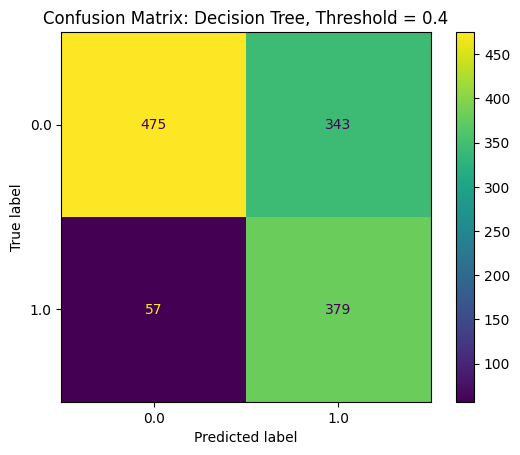

In [16]:
threshold = 0.4

y_pred_tree_threshold = (y_proba_tree >= threshold).astype(int)

print("Metriken Decision Tree mit Schwellenwert:", threshold)

print("Accuracy:", accuracy_score(y_test, y_pred_tree_threshold))
print("Precision weighted:", precision_score(y_test, y_pred_tree_threshold, average="weighted"))
print("Recall weighted:", recall_score(y_test, y_pred_tree_threshold, average="weighted"))
print("F1 weighted:", f1_score(y_test, y_pred_tree_threshold, average="weighted"))

print("Recall Hypertonie:", recall_score(y_test, y_pred_tree_threshold, pos_label=1))
print("Precision Hypertonie:", precision_score(y_test, y_pred_tree_threshold, pos_label=1))
print("F1 Hypertonie:", f1_score(y_test, y_pred_tree_threshold, pos_label=1))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree_threshold,
    cmap='viridis'
)

plt.title("Confusion Matrix: Decision Tree, Threshold = 0.4")
plt.show()

## 4.Modellvergelich

In [17]:
results = pd.DataFrame({
    
    "Modell": [
        "LogReg (0.5)",
        "LogReg (0.4)",
        "Random Forest (0.5)",
        "Random Forest (0.4)",
        "Decision Tree (0.5)",
        "Decision Tree (0.4)"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_threshold),
        accuracy_score(y_test, y_pred_forest),
        accuracy_score(y_test, y_pred_rf_threshold),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_tree_threshold)
    ],
    
    "Recall_Hypertonie": [
        recall_score(y_test, y_pred_log, pos_label=1),
        recall_score(y_test, y_pred_threshold, pos_label=1),
        recall_score(y_test, y_pred_forest, pos_label=1),
        recall_score(y_test, y_pred_rf_threshold, pos_label=1),
        recall_score(y_test, y_pred_tree, pos_label=1),
        recall_score(y_test, y_pred_tree_threshold, pos_label=1)
    ],
    
    "Precision_Hypertonie": [
        precision_score(y_test, y_pred_log, pos_label=1),
        precision_score(y_test, y_pred_threshold, pos_label=1),
        precision_score(y_test, y_pred_forest, pos_label=1),
        precision_score(y_test, y_pred_rf_threshold, pos_label=1),
        precision_score(y_test, y_pred_tree, pos_label=1),
        precision_score(y_test, y_pred_tree_threshold, pos_label=1)
    ],
    
    "F1_Hypertonie": [
        f1_score(y_test, y_pred_log, pos_label=1),
        f1_score(y_test, y_pred_threshold, pos_label=1),
        f1_score(y_test, y_pred_forest, pos_label=1),
        f1_score(y_test, y_pred_rf_threshold, pos_label=1),
        f1_score(y_test, y_pred_tree, pos_label=1),
        f1_score(y_test, y_pred_tree_threshold, pos_label=1)
    ],
    
    "ROC_AUC": [
        roc_auc_log,
        roc_auc_log,
        roc_auc_rf,
        roc_auc_rf,
        roc_auc_tree,
        roc_auc_tree
    ]
})

print(results)
results.sort_values(by="Recall_Hypertonie", ascending=False)

                Modell  Accuracy  Recall_Hypertonie  Precision_Hypertonie  \
0         LogReg (0.5)  0.737640           0.791284              0.591767   
1         LogReg (0.4)  0.704944           0.889908              0.546479   
2  Random Forest (0.5)  0.708931           0.504587              0.596206   
3  Random Forest (0.4)  0.709729           0.660550              0.571429   
4  Decision Tree (0.5)  0.712121           0.798165              0.560386   
5  Decision Tree (0.4)  0.681021           0.869266              0.524931   

   F1_Hypertonie   ROC_AUC  
0       0.677134  0.816194  
1       0.677138  0.816194  
2       0.546584  0.775041  
3       0.612766  0.775041  
4       0.658467  0.790687  
5       0.654577  0.790687  


,Modell,Accuracy,Recall_Hypertonie,Precision_Hypertonie,F1_Hypertonie,ROC_AUC
1,LogReg (0.4),0.704944,0.889908,0.546479,0.677138,0.816194
5,Decision Tree (0.4),0.681021,0.869266,0.524931,0.654577,0.790687
4,Decision Tree (0.5),0.712121,0.798165,0.560386,0.658467,0.790687
0,LogReg (0.5),0.737640,0.791284,0.591767,0.677134,0.816194
3,Random Forest (0.4),0.709729,0.660550,0.571429,0.612766,0.775041
2,Random Forest (0.5),0.708931,0.504587,0.596206,0.546584,0.775041


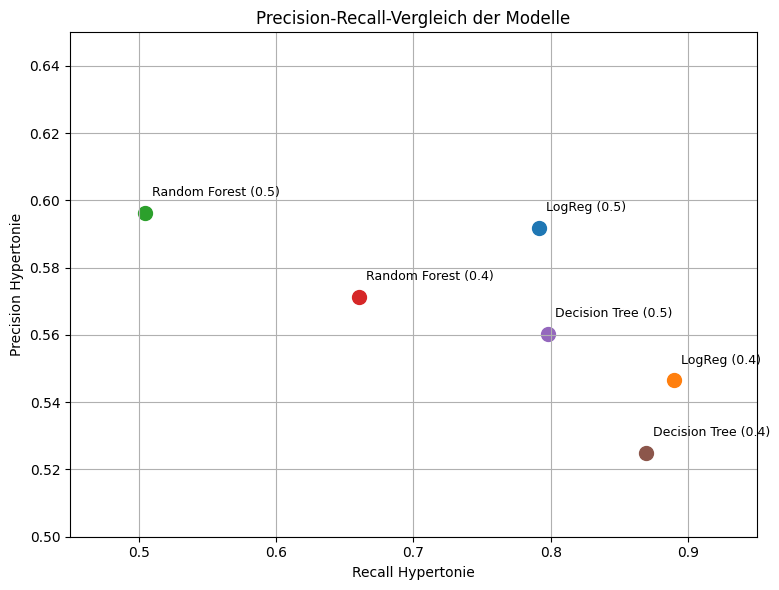

In [18]:
plt.figure(figsize=(8, 6))

for i in range(len(results)):
    plt.scatter(
        results.loc[i, "Recall_Hypertonie"],
        results.loc[i, "Precision_Hypertonie"],
        s=100
    )
    
    plt.text(
        results.loc[i, "Recall_Hypertonie"] + 0.005,
        results.loc[i, "Precision_Hypertonie"] + 0.005,
        results.loc[i, "Modell"],
        fontsize=9
    )

plt.xlim(0.45, 0.95)
plt.ylim(0.50, 0.65)

plt.xlabel("Recall Hypertonie")
plt.ylabel("Precision Hypertonie")
plt.title("Precision-Recall-Vergleich der Modelle")
plt.grid(True)
plt.tight_layout()
plt.show()

Modelle weiter rechts erkennen mehr tatsächliche Hypertonie-Fälle. Modelle weiter oben haben weniger falsch-positive Hypertonie-Vorhersagen. Die logistische Regression mit Schwellenwert 0,4 erreicht den höchsten Recall, während Random Forest mit Standardschwellenwert die höchste Precision, aber einen deutlich niedrigeren Recall zeigt.
- hoher Recall = mehr Hypertonie-Fälle erkannt
- hohe Precision = weniger falsch-positive Fälle

## Hypertonie-Risikoeinschätzung 

Nach der Modellierung wurde eine Feature-Importance-Analyse durchgeführt, um zu untersuchen, welche Eingangsvariablen die Vorhersage des Modells am stärksten beeinflussen. Die Analyse dient dazu, die Modellentscheidung besser nachvollziehbar zu machen und die Auswahl der Eingabevariablen für die Streamlit-Anwendung zu begründen.

Für die Anwendung sollen vor allem Merkmale berücksichtigt werden, die sowohl für das Modell relevant als auch für Nutzerinnen und Nutzer einfach selbst anzugeben sind. Dazu gehören beispielsweise Alter, Geschlecht, BMI, Taillenumfang sowie ausgewählte Lebensstilfaktoren. Laborwerte oder schwer zugängliche medizinische Informationen werden nicht einbezogen, um die Anwendung benutzerfreundlich zu halten.

Die Streamlit-App nutzt das trainierte Modell, um auf Grundlage der eingegebenen Werte eine Einschätzung für ein erhöhtes Hypertonie-Risiko auszugeben. Dabei handelt es sich nicht um eine medizinische Diagnose, sondern um ein datenbasiertes Screening-Modell. Die Anwendung kann mögliche Risikokonstellationen sichtbar machen, ersetzt jedoch keine ärztliche Untersuchung oder Blutdruckmessung.

### Feature-Importance-Analyse

Da als finales Modell eine logistische Regression verwendet wurde, basiert die Feature-Importance-Analyse auf den geschätzten **Modellkoeffizienten**. Die Koeffizienten zeigen, wie stark eine Variable die Vorhersage in Richtung Hypertonie oder Nicht-Hypertonie beeinflusst.

Positive Koeffizienten erhöhen die Wahrscheinlichkeit für die Klasse „Hypertonie“, während negative Koeffizienten die Wahrscheinlichkeit für „keine Hypertonie“ erhöhen. Für die Bewertung der Wichtigkeit wurde zusätzlich der absolute Wert der Koeffizienten betrachtet, da dieser unabhängig von der Richtung zeigt, wie stark eine Variable insgesamt zur Modellentscheidung beiträgt.

In [19]:
print(log_model.named_steps)

{'scaler': StandardScaler(), 'model': LogisticRegression(class_weight='balanced', max_iter=1000)}


In [22]:
# Feature-Namen aus den Trainingsdaten
feature_names = X_train.columns

# Koeffizienten aus der logistischen Regression holen ( Richtung des Einflusses)
coefficients = log_model.named_steps["model"].coef_[0]

# DataFrame erstellen
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Importance": abs(coefficients)
})

# Nach Wichtigkeit sortieren ( Stärke des Einflusses)
feature_importance = feature_importance.sort_values(
    by="Importance", 
    ascending=False
)

feature_importance

,Feature,Coefficient,Importance
1,age,1.033100,1.033100
5,waist_circumference(cm),0.556032,0.556032
3,height(cm),-0.430306,0.430306
2,weight(kg),0.347991,0.347991
4,bmi,-0.235416,0.235416
0,gender,-0.167094,0.167094


### Interpretation der Feature-Importance-Analyse

Die Feature-Importance-Analyse zeigt, dass das Alter den stärksten Einfluss auf die Vorhersage des logistischen Regressionsmodells hat. Der Koeffizient für `age` ist positiv und weist mit einem Importance-Wert von 1.033 den höchsten Wert auf. Das bedeutet, dass ein höheres Alter im Modell mit einer höheren Wahrscheinlichkeit für die Klasse „Hypertonie“ verbunden ist.

An zweiter Stelle steht der Taillenumfang `waist_circumference(cm)` mit einem positiven Koeffizienten von 0.556. Auch diese Variable erhöht im Modell die Wahrscheinlichkeit für Hypertonie. Dies ist fachlich plausibel, da ein größerer Taillenumfang häufig mit kardiometabolischen Risikofaktoren verbunden ist.

Die Körpergröße `height(cm)` weist einen negativen Koeffizienten von -0.430 auf. Das bedeutet, dass höhere Werte dieser Variable im Modell eher mit der Klasse „keine Hypertonie“ verbunden sind. Wichtig ist jedoch, diesen Zusammenhang vorsichtig zu interpretieren, da Körpergröße allein kein direkter Risikofaktor für Hypertonie ist. Der Effekt kann auch durch Zusammenhänge mit anderen Körpermaßen oder der Zusammensetzung des Datensatzes beeinflusst sein.

Das Körpergewicht `weight(kg)` hat einen positiven Koeffizienten von 0.348. Ein höheres Körpergewicht ist im Modell somit eher mit einer höheren Wahrscheinlichkeit für Hypertonie verbunden. Gleichzeitig ist zu beachten, dass Gewicht, BMI und Taillenumfang teilweise ähnliche Informationen über Körperzusammensetzung und Adipositas abbilden können.

Der `BMI` zeigt in diesem Modell einen negativen Koeffizienten von -0.235. Das wirkt auf den ersten Blick fachlich weniger intuitiv, da ein höherer BMI häufig mit einem erhöhten Hypertonierisiko verbunden ist. Dieser Befund sollte daher vorsichtig interpretiert werden. Eine mögliche Erklärung ist, dass BMI gemeinsam mit Gewicht, Körpergröße und Taillenumfang im Modell verwendet wurde. Dadurch können sich die Effekte der Variablen gegenseitig beeinflussen.

Das Geschlecht `gender` weist mit einer Importance von 0.167 den geringsten Einfluss unter den betrachteten Variablen auf. Der negative Koeffizient zeigt, dass die entsprechend codierte Geschlechtskategorie im Modell eher mit einer geringeren Wahrscheinlichkeit für Hypertonie verbunden ist.

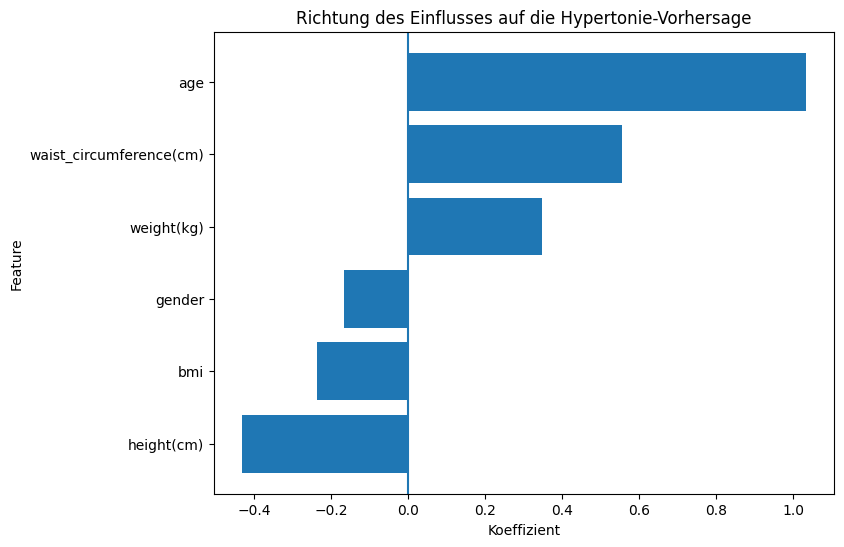

In [24]:
feature_importance_direction = feature_importance.sort_values(
    by="Coefficient", 
    ascending=True
)

plt.figure(figsize=(8, 6))

plt.barh(
    feature_importance_direction["Feature"],
    feature_importance_direction["Coefficient"]
)

plt.xlabel("Koeffizient")
plt.ylabel("Feature")
plt.title("Richtung des Einflusses auf die Hypertonie-Vorhersage")
plt.axvline(0)
plt.show()

Die Feature-Importance-Analyse zeigt, welche Variablen die Vorhersage des finalen Modells besonders stark beeinflussen. Positive Koeffizienten sprechen für eine höhere Wahrscheinlichkeit der Klasse „Hypertonie“, während negative Koeffizienten eher mit der Klasse „keine Hypertonie“ verbunden sind.

Insgesamt zeigt die Analyse, dass vor allem Alter und Taillenumfang die Modellvorhersage stark beeinflussen. Diese Merkmale sind daher besonders relevant für die spätere Streamlit-Anwendung. Gleichzeitig müssen die Ergebnisse als modellbasierte Zusammenhänge verstanden werden und dürfen nicht als kausale Ursachen interpretiert werden.